<a href="https://colab.research.google.com/github/shailvisrivas/HYBRID-FRAUD-DETECTION-ML/blob/main/hybrid_ml_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost openpyxl


In [3]:
# ==========================================================
# PART 1 - Data Loading & Feature Engineering
# ==========================================================

# ==========================
# 1. IMPORT LIBRARIES
# ==========================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import shap

# ==========================================================
# 2. LOAD DATASET
# ==========================================================

df = pd.read_excel("/content/best dataset.xlsx")

print("Dataset Loaded Successfully")
print("Total Rows :", len(df))

# ==========================================================
# 3. REMOVE EMPTY ROWS
# ==========================================================

df = df.dropna(how="all")

required_columns = [
    "Amount",
    "Merchant",
    "Device",
    "Location",
    "Payment_Mode",
    "Transaction_Timestamp"
]

df = df.dropna(subset=required_columns)

print("Valid Rows :", len(df))

# ==========================================================
# 4. DATE & TIME PROCESSING
# ==========================================================

df["Transaction_Timestamp"] = pd.to_datetime(
    df["Transaction_Timestamp"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Transaction_Timestamp"])

# Hour

df["Hour"] = df["Transaction_Timestamp"].dt.hour

# Day of Week

df["DayOfWeek"] = df["Transaction_Timestamp"].dt.dayofweek

# Weekend

df["Weekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

# Night Transaction

df["Night"] = (
    (df["Hour"] >= 22) |
    (df["Hour"] <= 5)
).astype(int)

# ==========================================================
# 5. FEATURE ENGINEERING
# ==========================================================

# Log Amount

df["Log_Amount"] = np.log1p(df["Amount"])

# Z-Score

mean_amount = df["Amount"].mean()
std_amount = df["Amount"].std()

df["Amount_ZScore"] = (
    df["Amount"] - mean_amount
) / std_amount

# ==========================================================
# 6. TRAINING & UNSEEN DATA
# ==========================================================

train_df = df[df["Fraud"].notna()].copy()

unseen_df = df[df["Fraud"].isna()].copy()

print("\nTraining Transactions :", len(train_df))
print("Unseen Transactions :", len(unseen_df))

# ==========================================================
# 7. LABEL ENCODING
# ==========================================================

categorical_cols = [
    "Merchant",
    "Device",
    "Location",
    "Payment_Mode"
]

encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    train_df[col] = encoder.fit_transform(
        train_df[col].astype(str)
    )

    encoders[col] = encoder

# ==========================================================
# SAFE ENCODER FOR NEW TRANSACTIONS
# ==========================================================

def safe_encode(column, value):

    encoder = encoders[column]

    value = str(value)

    if value in encoder.classes_:
        return encoder.transform([value])[0]

    return 0

# ==========================================================
# 8. SELECT FEATURES
# ==========================================================

features = [

    "Merchant",

    "Device",

    "Location",

    "Payment_Mode",

    "Amount",

    "Log_Amount",

    "Amount_ZScore",

    "Hour",

    "Night",

    "Weekend"

]

X = train_df[features]

y = train_df["Fraud"].astype(int)

print("\nSelected Features")

print(features)

# ==========================================================
# 9. TRAIN / TEST SPLIT
# ==========================================================

X_train_base, X_test_base, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("\nTraining Shape :", X_train_base.shape)

print("Testing Shape :", X_test_base.shape)

print("\nFraud Distribution")

print(y.value_counts())

print("\nFraud Percentage")

print((y.value_counts(normalize=True) * 100).round(2))

Dataset Loaded Successfully
Total Rows : 817
Valid Rows : 817

Training Transactions : 813
Unseen Transactions : 4

Selected Features
['Merchant', 'Device', 'Location', 'Payment_Mode', 'Amount', 'Log_Amount', 'Amount_ZScore', 'Hour', 'Night', 'Weekend']

Training Shape : (650, 10)
Testing Shape : (163, 10)

Fraud Distribution
Fraud
0    693
1    120
Name: count, dtype: int64

Fraud Percentage
Fraud
0    85.24
1    14.76
Name: proportion, dtype: float64



Training Isolation Forest...
Isolation Forest Trained Successfully.
Continuous anomaly scores generated.

Training CatBoost...
CatBoost Training Completed.

MODEL PERFORMANCE
Accuracy  : 97.55%
Precision : 0.8846
Recall    : 0.9583
F1 Score  : 0.9200
ROC-AUC   : 0.9895

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       139
           1       0.88      0.96      0.92        24

    accuracy                           0.98       163
   macro avg       0.94      0.97      0.95       163
weighted avg       0.98      0.98      0.98       163


Confusion Matrix

[[136   3]
 [  1  23]]


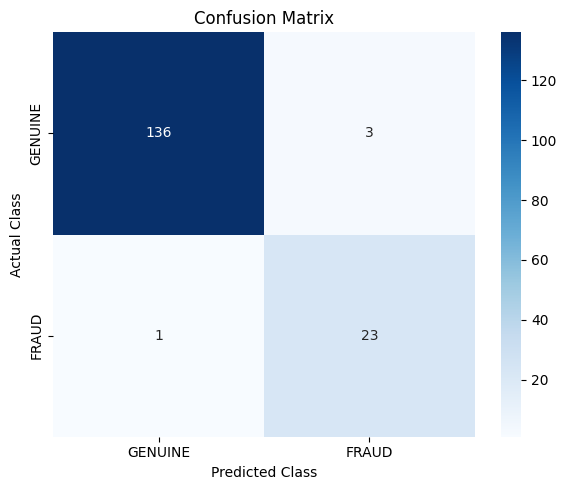

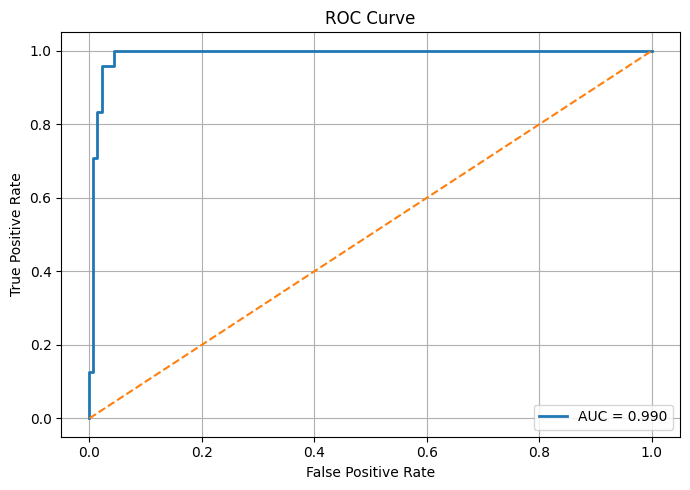


Feature Importance

          Feature  Importance
0        Merchant   24.148552
5      Log_Amount   12.279840
4          Amount   11.428056
7            Hour   10.567962
6   Amount_ZScore    9.440158
10  Anomaly_Score    8.398129
3    Payment_Mode    7.356785
9         Weekend    5.677454
1          Device    3.986872
2        Location    3.470752
8           Night    3.245442


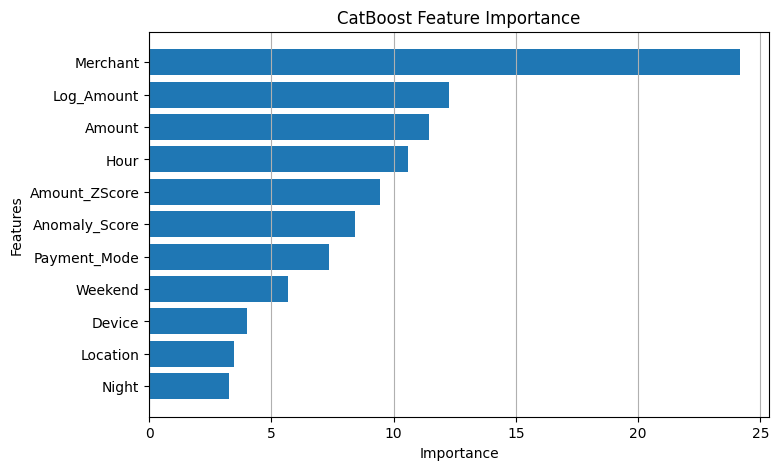


Hybrid Model Training Complete.


In [4]:
# ==========================================================

# PART 2 - Hybrid Model Training & Evaluation

# ==========================================================



# ==========================================================

# 10. TRAIN ISOLATION FOREST

# ==========================================================



print("\nTraining Isolation Forest...")


iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples="auto",
    random_state=42
)




iso.fit(X_train_base)



print("Isolation Forest Trained Successfully.")



# ==========================================================

# 11. GENERATE CONTINUOUS ANOMALY SCORES

# ==========================================================



# Raw anomaly scores

train_raw_scores = -iso.decision_function(X_train_base)

test_raw_scores = -iso.decision_function(X_test_base)

# Normalize scores between 0 and 1

min_score = train_raw_scores.min()
max_score = train_raw_scores.max()

# Prevent division by zero
denom = max(max_score - min_score, 1e-8)

train_scores = (train_raw_scores - min_score) / denom
test_scores = (test_raw_scores - min_score) / denom

train_scores = np.clip(train_scores, 0, 1)
test_scores = np.clip(test_scores, 0, 1)




# Add anomaly score



X_train = X_train_base.copy()

X_test = X_test_base.copy()



X_train["Anomaly_Score"] = train_scores

X_test["Anomaly_Score"] = test_scores



print("Continuous anomaly scores generated.")



# ==========================================================

# 12. TRAIN CATBOOST

# ==========================================================
print("\nTraining CatBoost...")

model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.03,
    depth=7,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True,
    early_stopping_rounds=50
)

print("CatBoost Training Completed.")




# ==========================================================

# 13. PREDICTIONS

# ==========================================================

probabilities = model.predict_proba(X_test)[:,1]

best_threshold = 0.50
best_f1 = 0

for threshold in np.arange(0.30,0.71,0.01):

    pred = (probabilities >= threshold).astype(int)

    score = f1_score(y_test,pred)

    if score > best_f1:

        best_f1 = score
        best_threshold = threshold

predictions = (probabilities >= best_threshold).astype(int)


# ==========================================================

# 14. MODEL EVALUATION

# ==========================================================



accuracy = accuracy_score(y_test,predictions)



precision = precision_score(y_test,predictions)



recall = recall_score(y_test,predictions)



f1 = f1_score(y_test,predictions)



roc = roc_auc_score(y_test,probabilities)



print("\n===================================")

print("MODEL PERFORMANCE")

print("===================================")



print(f"Accuracy  : {accuracy*100:.2f}%")



print(f"Precision : {precision:.4f}")



print(f"Recall    : {recall:.4f}")



print(f"F1 Score  : {f1:.4f}")



print(f"ROC-AUC   : {roc:.4f}")



# ==========================================================

# 15. CLASSIFICATION REPORT

# ==========================================================



print("\nClassification Report\n")



print(



    classification_report(



        y_test,



        predictions



    )



)



# ==========================================================
# 16. CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    predictions
)

print("\nConfusion Matrix\n")
print(cm)

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Create Confusion Matrix figure
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["GENUINE", "FRAUD"],
    yticklabels=["GENUINE", "FRAUD"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close("all")

# Add visible space between the two figures
display(HTML("<div style='height: 80px;'></div>"))


# ==========================================================
# 17. ROC CURVE
# ==========================================================

fpr, tpr, _ = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close("all")
# ==========================================================

# 18. FEATURE IMPORTANCE

# ==========================================================



importance = model.get_feature_importance()



feature_importance = pd.DataFrame({



    "Feature":X_train.columns,



    "Importance":importance



})



feature_importance = feature_importance.sort_values(



    by="Importance",



    ascending=False



)



print("\nFeature Importance\n")



print(feature_importance)



plt.figure(figsize=(8,5))



plt.barh(



    feature_importance["Feature"],



    feature_importance["Importance"]



)



plt.gca().invert_yaxis()



plt.xlabel("Importance")



plt.ylabel("Features")



plt.title("CatBoost Feature Importance")



plt.grid(axis="x")



plt.show()



print("\nHybrid Model Training Complete.")

In [5]:
# ==========================================================
# PART 3 - ARDE + Prediction + Risk Assessment
# ==========================================================

import textwrap
import numpy as np
import pandas as pd

# ==========================================================
# 19. DYNAMIC AMOUNT THRESHOLDS
# ==========================================================

Q1 = train_df["Amount"].quantile(0.25)
Q3 = train_df["Amount"].quantile(0.75)

IQR = Q3 - Q1

HIGH_AMOUNT = Q3 + (1.5 * IQR)
MEDIUM_AMOUNT = train_df["Amount"].median()

print("\nDynamic Thresholds")
print(f"Medium Amount Threshold : ₹{MEDIUM_AMOUNT:.2f}")
print(f"High Amount Threshold   : ₹{HIGH_AMOUNT:.2f}")


# ==========================================================
# BASE FEATURES USED BY ISOLATION FOREST
# ==========================================================

base_features = [
    col for col in X_train.columns
    if col != "Anomaly_Score"
]


# ==========================================================
# 20. ADAPTIVE RISK DECISION ENGINE (ARDE)
# ==========================================================

def arde_engine(
    probability,
    anomaly_score,
    amount,
    hour,
    merchant,
    device,
    location,
    payment_mode,
    # NOTE: merchant, device, location, and payment_mode are currently
    # unused in the risk calculation. They are kept in the signature
    # for future extensions (e.g. merchant/device-based risk rules)
    # and to keep the function call self-documenting at the call site.
    threshold
):

    reasons = []

    # ------------------------------------------------------
    # 1. AMOUNT RISK
    # ------------------------------------------------------

    if amount >= HIGH_AMOUNT:

        amount_risk = 1.0

        reasons.append(
            f"The transaction amount of ₹{amount:,.2f} "
            f"is above the high-risk threshold of "
            f"₹{HIGH_AMOUNT:,.2f}."
        )

    elif amount >= MEDIUM_AMOUNT:

        amount_risk = 0.60

        reasons.append(
            f"The transaction amount of ₹{amount:,.2f} "
            f"is above the medium-risk threshold of "
            f"₹{MEDIUM_AMOUNT:,.2f}."
        )

    else:

        amount_risk = 0.20


    # ------------------------------------------------------
    # 2. TIME RISK
    # ------------------------------------------------------

    if hour >= 22 or hour <= 5:

        time_risk = 1.0

        reasons.append(
            f"The transaction occurred during the "
            f"defined high-risk night period ({hour:02d}:00 hrs)."
        )

    else:

        time_risk = 0.0


    # ------------------------------------------------------
    # 3. ANOMALY REASONING
    # ------------------------------------------------------

    if anomaly_score >= 0.75:

        reasons.append(
            "The transaction shows a high level of "
            "anomalous behaviour."
        )

    elif anomaly_score >= 0.50:

        reasons.append(
            "The transaction shows a moderate level of "
            "anomalous behaviour."
        )

    else:

        reasons.append(
            "No significant anomalous behaviour was detected."
        )


    # ------------------------------------------------------
    # 4. ARDE RISK SCORE
    # ------------------------------------------------------

    risk_score = (

        0.55 * probability +

        0.25 * anomaly_score +

        0.10 * amount_risk +

        0.10 * time_risk

    )

    risk_score = np.clip(
        risk_score,
        0.0,
        1.0
    )


    # ------------------------------------------------------
    # 5. RISK LEVEL
    # ------------------------------------------------------

    if risk_score >= 0.70:

        risk_level = "HIGH"

    elif risk_score >= 0.40:

        risk_level = "MODERATE"

    else:

        risk_level = "LOW"


    # ------------------------------------------------------
    # 6. BINARY MODEL PREDICTION
    # ------------------------------------------------------

    if probability >= threshold:

        prediction = "FRAUD"

    else:

        prediction = "GENUINE"


    # ------------------------------------------------------
    # 7. RECOMMENDED ACTION
    #
    # Prediction and risk are treated separately.
    # ------------------------------------------------------

    if prediction == "FRAUD":

        if risk_level == "HIGH":

            recommended_action = (
                "Block transaction and initiate immediate verification."
            )

        elif risk_level == "MODERATE":

            recommended_action = (
                "Require secondary authentication before completing the transaction."
            )

        else:

            recommended_action = (
                "Require additional verification before completing the transaction."
            )

    else:

        if risk_level == "HIGH":

            recommended_action = (
                "Require secondary authentication due to elevated risk."
            )

        elif risk_level == "MODERATE":

            recommended_action = (
                "Require secondary authentication before completing the transaction."
            )

        else:

            recommended_action = (
                "Approve transaction. No significant risk indicators detected."
            )


    # ------------------------------------------------------
    # 8. NATURAL-LANGUAGE FRAUD ANALYSIS SUMMARY
    # ------------------------------------------------------

    if prediction == "FRAUD":

        if risk_level == "HIGH":

            if amount >= HIGH_AMOUNT and anomaly_score >= 0.50:

                summary = (
                    f"This transaction is highly likely to be fraudulent. "
                    f"The amount of ₹{amount:,.2f} is significantly higher "
                    f"than the usual transaction range, and the transaction "
                    f"also shows unusual behaviour according to the anomaly "
                    f"detector. These factors result in a high-risk assessment."
                )

            elif amount >= HIGH_AMOUNT:

                summary = (
                    f"This transaction is highly likely to be fraudulent. "
                    f"The amount of ₹{amount:,.2f} is significantly higher "
                    f"than the usual transaction range. This contributes "
                    f"to a high-risk assessment."
                )

            elif anomaly_score >= 0.50:

                summary = (
                    "This transaction is highly likely to be fraudulent. "
                    "The transaction also shows unusual behaviour according "
                    "to the anomaly detector. These factors result in a "
                    "high-risk assessment."
                )

            else:

                summary = (
                    "This transaction is highly likely to be fraudulent. "
                    "The prediction is supported by the overall transaction "
                    "risk indicators, resulting in a high-risk assessment."
                )

        else:

            summary = (
                "This transaction is classified as fraudulent. "
                "The transaction shows suspicious characteristics, while "
                "the combined model and transaction-level indicators result "
                f"in a {risk_level.lower()}-risk assessment."
            )

    else:

        if risk_level == "LOW":

            summary = (
                "This transaction appears consistent with normal "
                "transaction behaviour. No significant suspicious "
                "characteristics were identified, resulting in a "
                "low-risk assessment."
            )

        elif risk_level == "MODERATE":

            if anomaly_score >= 0.50 and time_risk == 1.0:

                summary = (
                    "This transaction is classified as genuine, but some "
                    "unusual characteristics were detected. The transaction "
                    "shows anomalous behaviour and occurred during the "
                    "defined high-risk period. These factors result in a "
                    "moderate-risk assessment."
                )

            elif anomaly_score >= 0.50:

                summary = (
                    "This transaction is classified as genuine, but some "
                    "unusual characteristics were detected. The anomaly "
                    "detector identified behaviour that differs from the "
                    "normal transaction pattern. These factors result in "
                    "a moderate-risk assessment."
                )

            elif time_risk == 1.0:

                summary = (
                    "This transaction is classified as genuine, but it "
                    "occurred during the defined high-risk period. This "
                    "factor increases the overall risk and results in a "
                    "moderate-risk assessment."
                )

            else:

                summary = (
                    "This transaction is classified as genuine, but some "
                    "transaction-level risk indicators are present. "
                    "These factors result in a moderate-risk assessment."
                )

        else:

            summary = (
                "This transaction is classified as genuine, but the "
                "combined transaction-level indicators result in an "
                "elevated risk assessment. Additional verification "
                "is recommended."
            )


    return (
        risk_score,
        risk_level,
        prediction,
        recommended_action,
        summary,
        reasons
    )


# ==========================================================
# 21. PREDICT UNSEEN TRANSACTIONS
# ==========================================================

print("\n")

if unseen_df.empty:

    print("\nNo unseen transactions available.")

else:

    total_transactions = len(unseen_df)

    for count, (_, row) in enumerate(
        unseen_df.iterrows(),
        start=1
    ):

        amount = float(row["Amount"])

        hour = int(row["Hour"])

        z_score = (
            amount - mean_amount
        ) / (std_amount + 1e-6)


        # --------------------------------------------------
        # 1. BUILD BASE FEATURES
        # --------------------------------------------------

        base_dict = {

            "Merchant":
                safe_encode(
                    "Merchant",
                    row["Merchant"]
                ),

            "Device":
                safe_encode(
                    "Device",
                    row["Device"]
                ),

            "Location":
                safe_encode(
                    "Location",
                    row["Location"]
                ),

            "Payment_Mode":
                safe_encode(
                    "Payment_Mode",
                    row["Payment_Mode"]
                ),

            "Amount":
                amount,

            "Log_Amount":
                np.log1p(amount),

            "Amount_ZScore":
                z_score,

            "Hour":
                hour,

            "Night":
                int(
                    hour >= 22 or
                    hour <= 5
                ),

            "Weekend":
                int(row["Weekend"])

        }


        tx_base = pd.DataFrame(
            [base_dict]
        )[base_features]


        # --------------------------------------------------
        # 2. ISOLATION FOREST ANOMALY SCORE
        # --------------------------------------------------

        raw_score = -iso.decision_function(
            tx_base
        )[0]

        denom = (
            max_score - min_score
        )

        if denom == 0:

            denom = 1.0


        anomaly_score = np.clip(

            (
                raw_score - min_score
            ) / denom,

            0.0,
            1.0

        )


        # --------------------------------------------------
        # 3. BUILD CATBOOST FEATURE SET
        # --------------------------------------------------

        tx_full = tx_base.copy()

        tx_full["Anomaly_Score"] = (
            anomaly_score
        )

        tx = tx_full[
            X_train.columns
        ].copy()


        # --------------------------------------------------
        # 4. CATBOOST PREDICTION
        # --------------------------------------------------

        fraud_probability = float(
            model.predict_proba(tx)[0][1]
        )

        prediction_value = int(
            fraud_probability >= best_threshold
        )


        if prediction_value == 1:

            prediction = "FRAUD"

        else:

            prediction = "GENUINE"


        # --------------------------------------------------
        # 5. ARDE RISK ASSESSMENT
        # --------------------------------------------------

        (
            risk_score,
            risk_level,
            arde_prediction,
            recommended_action,
            summary,
            summary_bullets

        ) = arde_engine(

            probability=fraud_probability,

            anomaly_score=anomaly_score,

            amount=amount,

            hour=hour,

            merchant=row["Merchant"],

            device=row["Device"],

            location=row["Location"],

            payment_mode=row["Payment_Mode"],

            threshold=best_threshold

        )


        txn_id = row["Transaction_ID"]


        # --------------------------------------------------
        # 6. OUTPUT REPORT
        # --------------------------------------------------

        print("\n")

        print(
            "══════════════════════════════════════════════════════════════════════"
        )

        print(
            f"TRANSACTION {count} OF {total_transactions}"
        )

        print(
            "══════════════════════════════════════════════════════════════════════"
        )


        print(
            f"\nTransaction ID : {txn_id}"
        )

        print(
            f"Analysis Time  : "
            f"{pd.Timestamp.now().strftime('%d-%m-%Y %H:%M:%S')}"
        )


        # --------------------------------------------------
        # TRANSACTION CONTEXT
        # --------------------------------------------------

        print(
            "\n------------------------------------------------------------"
        )

        print(
            "TRANSACTION CONTEXT"
        )

        print(
            "------------------------------------------------------------"
        )

        print(
            f"Merchant          : {row['Merchant']}"
        )

        print(
            f"Payment Mode      : {row['Payment_Mode']}"
        )

        print(
            f"Device            : {row['Device']}"
        )

        print(
            f"Location          : {row['Location']}"
        )

        print(
            f"Amount            : ₹{amount:,.2f}"
        )

        print(
            "Transaction Time  : "
            f"{pd.to_datetime(row['Transaction_Timestamp']).strftime('%d-%m-%Y %H:%M:%S')}"
        )


        # --------------------------------------------------
        # FRAUD ANALYSIS RESULT
        # --------------------------------------------------

        print(
            "\n------------------------------------------------------------"
        )

        print(
            "FRAUD ANALYSIS RESULT"
        )

        print(
            "------------------------------------------------------------"
        )

        print(
            f"Fraud Probability : "
            f"{fraud_probability * 100:.2f}%"
        )

        print(
            f"Anomaly Score     : "
            f"{anomaly_score:.2f}"
        )

        print(
            f"Risk Score        : "
            f"{risk_score * 100:.2f}%"
        )

        print(
            f"Prediction        : "
            f"{'🔴' if prediction == 'FRAUD' else '🟢'} "
            f"{prediction}"
        )

        print(
            f"Risk Level        : "
            f"{'🔴' if risk_level == 'HIGH' else '🟡' if risk_level == 'MODERATE' else '🟢'} "
            f"{risk_level}"
        )


        # --------------------------------------------------
        # FRAUD ANALYSIS SUMMARY
        # --------------------------------------------------

        print(
            "\n------------------------------------------------------------"
        )

        print(
            "FRAUD ANALYSIS SUMMARY"
        )

        print(
            "------------------------------------------------------------"
        )

        for line in textwrap.wrap(summary, width=65):
            print(line)


        # --------------------------------------------------
        # RECOMMENDED ACTION
        # --------------------------------------------------

        print(
            "\n------------------------------------------------------------"
        )

        print(
            "RECOMMENDED ACTION"
        )

        print(
            "------------------------------------------------------------"
        )

        print(recommended_action)


        print(
            "\n══════════════════════════════════════════════════════════════════════"
        )

        print(
            f"END OF ANALYSIS : {txn_id}"
        )

        print(
            "══════════════════════════════════════════════════════════════════════"
        )


print("\n")

print(
    "*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*"
)

print(
    "Analysis Completed Successfully."
)

print(
    "*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*"
)


Dynamic Thresholds
Medium Amount Threshold : ₹7718.00
High Amount Threshold   : ₹24003.00




══════════════════════════════════════════════════════════════════════
TRANSACTION 1 OF 4
══════════════════════════════════════════════════════════════════════

Transaction ID : TXN99754834
Analysis Time  : 21-08-2026 14:57:56

------------------------------------------------------------
TRANSACTION CONTEXT
------------------------------------------------------------
Merchant          : BookMyShow
Payment Mode      : UPI
Device            : Web
Location          : Ahmedabad
Amount            : ₹1,855.00
Transaction Time  : 29-01-2025 13:14:11

------------------------------------------------------------
FRAUD ANALYSIS RESULT
------------------------------------------------------------
Fraud Probability : 5.75%
Anomaly Score     : 0.22
Risk Score        : 10.55%
Prediction        : 🟢 GENUINE
Risk Level        : 🟢 LOW

------------------------------------------------------------
FRAUD ANALYSIS